# Estudio dqdv y ajustes sobre ARBIN-NMC04


In [38]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl


✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [39]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

In [40]:
# --- carga de datos ---
nombre_dataset = 'arbin-NMC04'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())


Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 16


## Primero vemos señal como viene

In [41]:
reload(pr)
reload(pl)
reload(utl)

<module 'utils_deriv' from '/home/mariajose/proc-icdv/src/utils_deriv.py'>

In [42]:
# --- Selección de ciclos ---
ciclos_sel_todos = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    excluir={list(dict_ciclos_sep.keys())[0], max(dict_ciclos_sep.keys()), list(dict_ciclos_sep.keys())[-2]}, # excluyo el primero, último y penúltimo
    #excluir={list(dict_ciclos_sep.keys())[0], max(dict_ciclos_sep.keys())}, # excluyo el primero y el último
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 13 ciclos seleccionados
   → [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


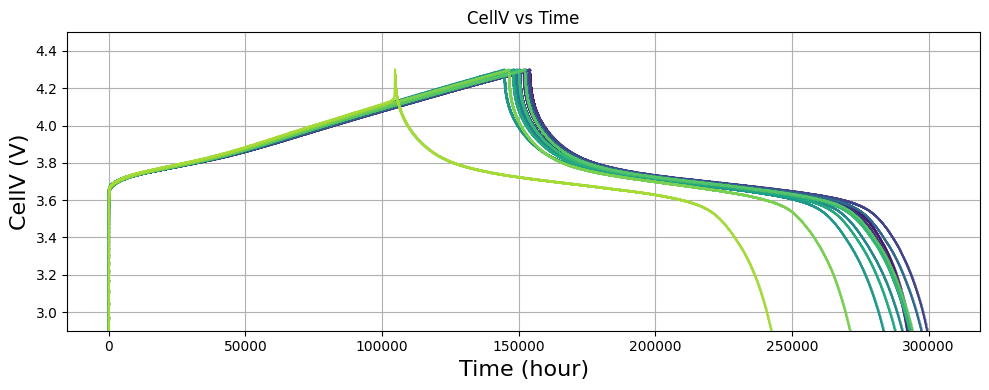

In [43]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos))] #if i == 0]
pl.plot_n_cycles_tvsV(ciclos_sel_grafico, dict_ciclos_sep, nombre_dataset, Path('../tmp'))

In [44]:
reload(pl)

<module 'plotting' from '/home/mariajose/proc-icdv/src/plotting.py'>

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


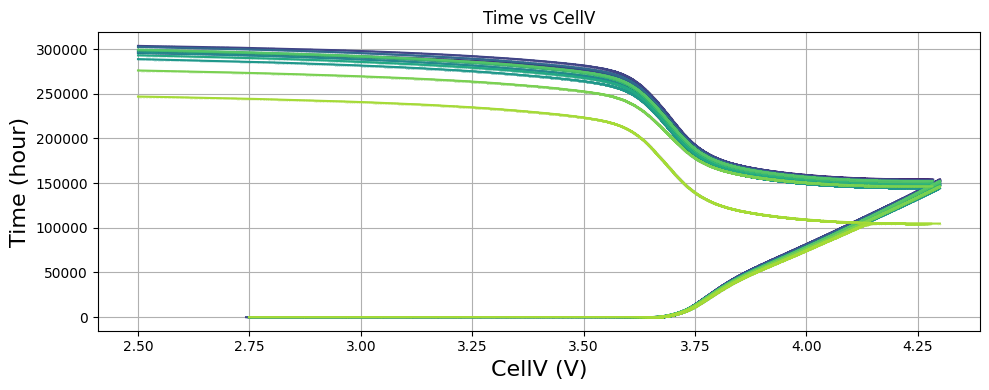

In [45]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos))] #if i == 0]
pl.plot_n_cycles_Vvst(ciclos_sel_grafico, dict_ciclos_sep, nombre_dataset, Path('../tmp'))

La capacidad máxima es 23160.416 mAh y se alcanza en el ciclo 2.


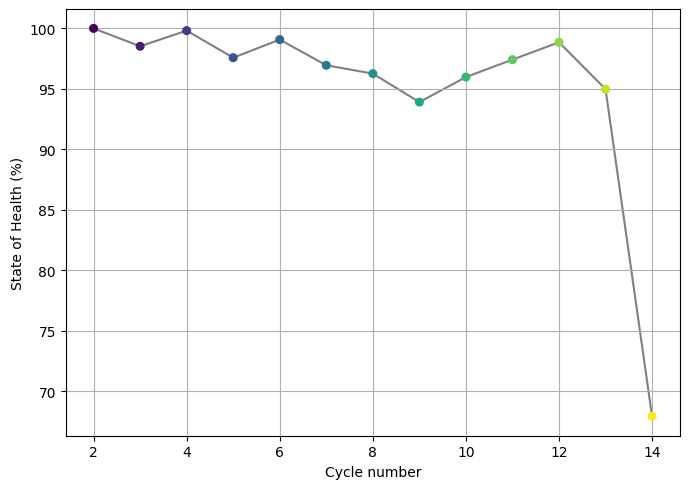

(    ciclo          qmax         soh
 0       2  23160.416263  100.000000
 1       3  22818.248997   98.522620
 2       4  23117.922709   99.816525
 3       5  22599.596322   97.578541
 4       6  22945.803733   99.073365
 5       7  22454.305891   96.951219
 6       8  22294.700388   96.262088
 7       9  21749.799512   93.909364
 8      10  22228.696371   95.977102
 9      11  22562.445989   97.418137
 10     12  22894.697279   98.852702
 11     13  21997.243361   94.977755
 12     14  15734.873053   67.938645,
 np.float64(23160.41626328548),
 2)

In [46]:
pl.plot_soh(
    dict_ciclos_sep,
    ciclos_sel_todos,
    nombre_dataset, 
    Path('../tmp')
)

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


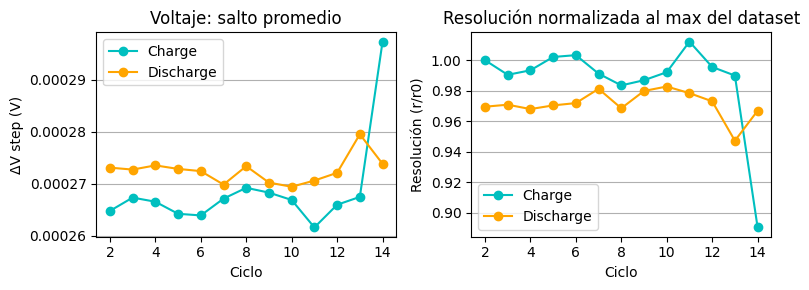

Puntos promedio por ventana de 2 mV:


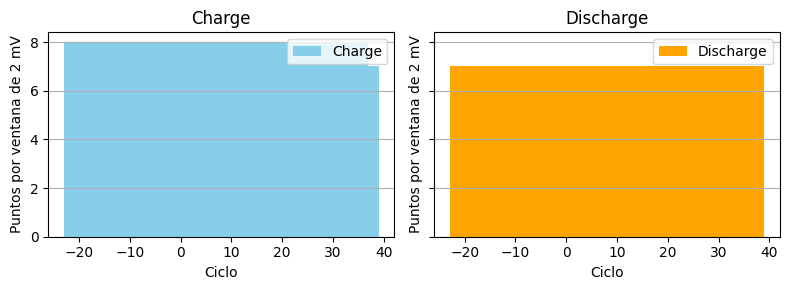

In [47]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_sep)

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

In [48]:
import matplotlib.pyplot as plt

In [49]:
def grafico_QV(ciclo, x=dict_ciclos_sep[3]['Ch']['CellV'], y=dict_ciclos_sep[3]['Ch']['Q'], xlim=None, ylim=None):

    plt.figure(figsize=(6,5))
    plt.scatter(x,y, s=2)
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.title(f'Cycle {ciclo} - {x.name} vs {y.name}')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.show()

Vemos la señal completa


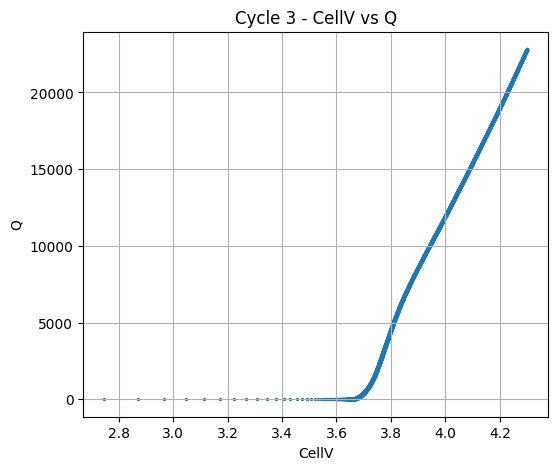

In [50]:
print('Vemos la señal completa')
grafico_QV(3)

Vemos el comienzo de la señal


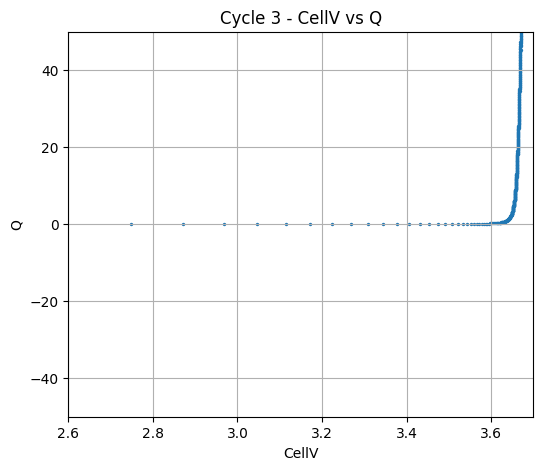

In [51]:
print('Vemos el comienzo de la señal')
grafico_QV(3, xlim=(2.6,3.7), ylim=(-50,50))

Vemos el comienzo de la señal truncando extremos (primeros 20 puntos)


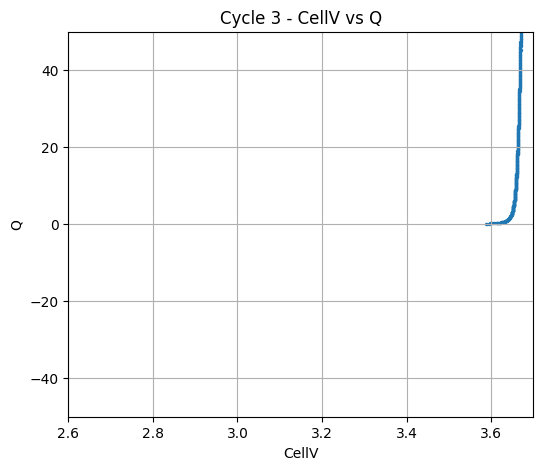

In [52]:
print('Vemos el comienzo de la señal truncando extremos (primeros 20 puntos)')
grafico_QV(3, dict_ciclos_sep[3]['Ch']['CellV'][26:], dict_ciclos_sep[3]['Ch']['Q'][26:], xlim=(2.6,3.7), ylim=(-50,50))

Vemos el final de la señal. Parece que no es necesario truncar puntos finales


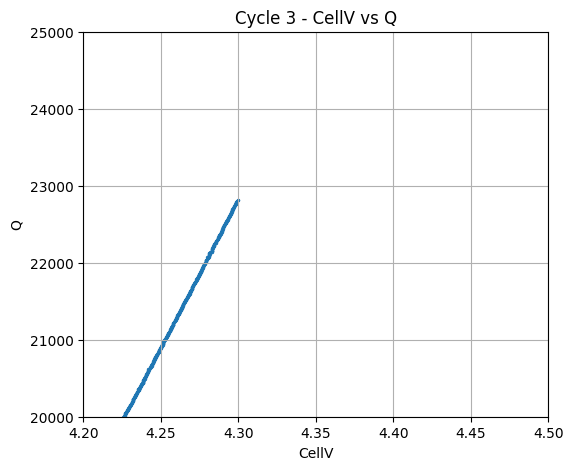

In [53]:
print('Vemos el final de la señal. Parece que no es necesario truncar puntos finales')
grafico_QV(3, xlim=(4.2,4.5), ylim=(20000,25000))

Vemos con mas zoom el comienzo de la señal.


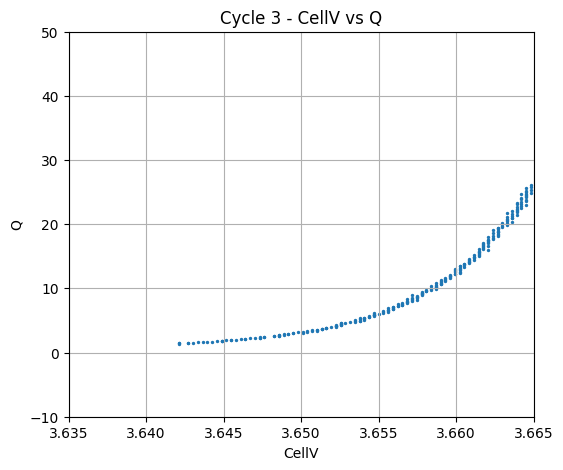

In [54]:
print('Vemos con mas zoom el comienzo de la señal.')
grafico_QV(3, dict_ciclos_sep[3]['Ch']['CellV'][80:], dict_ciclos_sep[3]['Ch']['Q'][80:], xlim=(3.635,3.665), ylim=(-10,50))

Acá podemos ver dos cosas:

1. los primeros puntos (al menos 80 del comienzo de la curva de carga) tienen menor resolución en voltaje, arruinan filtro y derivada hay que truncarlos.

2. se ve un equiespaciado constante que tiene que ver con la cantidad de dígitos máxima que el Arbin escribe en el excel.

3. hay distintos puntos de Q que se apilan para un mismo valor de voltaje. Esto habla de que en realidad no tiene tanta accuracy el Arbin, que no tiene tanta precision y esos últimos dígitos están dentro de la incertidumbre experimental.

Se pueden hacer dos cosas:
- (a)  redondear los valores de voltaje hasta 0.001 V (o sea 1 mV). Esto reduciría la resolución de voltaje que probablemente sea ficticia

- (b) hacer "aggregate", que para cada valor de voltaje, promedio los valores de Q. Esto sería para que el filtro pueda funcionar bien con un solo valor de V para cada Q. Esto se puede hacer habiendo hecho (a) o no.


IDEA: también, en vez de aplicar filtro savitzky-golay, se puede interpolar agregando muchos puntos entre los puntos reales, y derivando punto a punto esa curva.

## Pruebo hacer aggregate solo: (b)

In [55]:
reload(utl)

<module 'utils_deriv' from '/home/mariajose/proc-icdv/src/utils_deriv.py'>

In [56]:
dict_ciclos_ag = dr.agrupar_por_voltaje_todos(dict_ciclos_sep, n_decimales=8, metodo='mean')

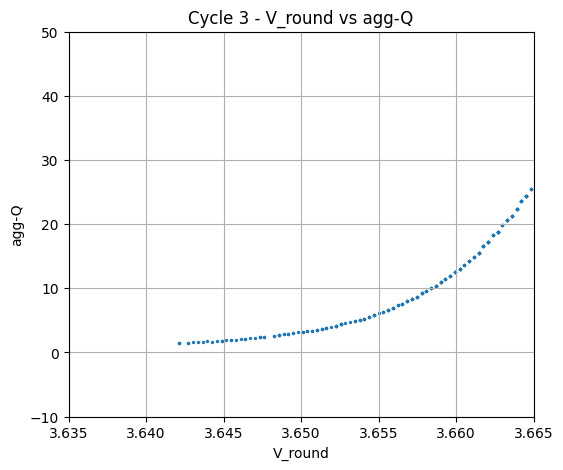

In [57]:
grafico_QV(3, dict_ciclos_ag[3]['Ch']['V_round'][80:], dict_ciclos_ag[3]['Ch']['agg-Q'][80:], xlim=(3.635,3.665), ylim=(-10,50))

In [58]:
dict_ciclos_ag_truncado = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_ag.items()}
dict_ciclos_ag_truncado = dr.truncar_señal(ciclos_sel_todos, dict_ciclos_ag_truncado, Q='agg-Q', CellV='V_round', n_dis=(90,90), n_ch=(90,90))

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


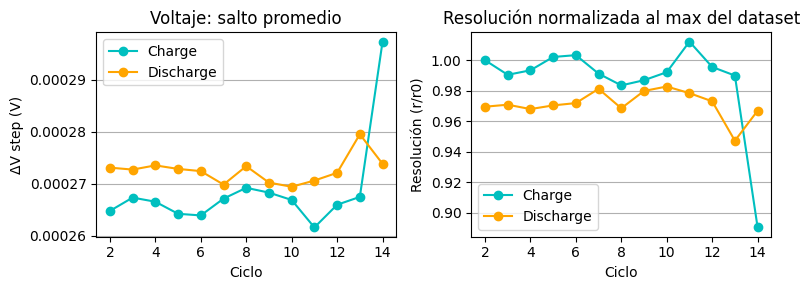

Puntos promedio por ventana de 2 mV:


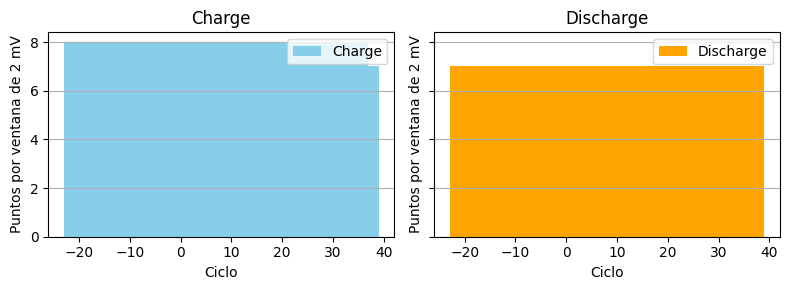

In [59]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_ag, x='V_round')

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

In [72]:
# prueba rápida antes de llamar a la función
c = ciclos_sel_grafico[0]               # tomar un ciclo de ejemplo
print(dict_ciclos_ag[c].keys())         # debe mostrar 'Ch' y 'Dis'
print(dict_ciclos_ag[c]['Ch'].columns)  # verificar columnas (p.e. 'agg-Q', 'V_round')
print(dict_ciclos_ag[c]['Ch'].dtypes)


dict_keys(['Ch', 'Dis'])
Index(['Time', 'Current', 'CellV', 'Q', 'V_round', 'agg-Q', 'agg-Q_std',
       'agg-CellV'],
      dtype='object')
Time         float64
Current      float64
CellV        float64
Q            float64
V_round      float64
agg-Q        float64
agg-Q_std    float64
agg-CellV    float64
dtype: object


In [95]:
reload(dr)

<module 'deriv' from '/home/mariajose/proc-icdv/src/deriv.py'>

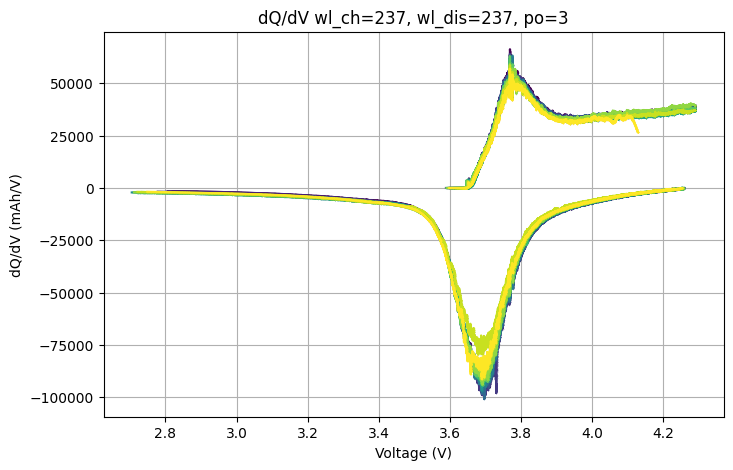

In [96]:
dict_ciclos_ag_truncado = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_ag.items()}
dict_ciclos_ag_truncado = dr.truncar_señal(ciclos_sel_todos, dict_ciclos_ag_truncado, Q='agg-Q', CellV='V_round', n_dis=(90,90), n_ch=(30,90))
dict_ciclos_ag_truncado =  dr.plot_dqdV(ciclos_sel_todos, dict_ciclos_ag_truncado, Q='agg-Q', CellV='V_round', wl_dis=237, wl_ch=237)

In [87]:
reload(dr)

<module 'deriv' from '/home/mariajose/proc-icdv/src/deriv.py'>

        agg-Q   V_round
0  209.029782  3.687246
1  209.029782  3.687246
2  212.571147  3.687553
3  212.571147  3.687553
4  209.029782  3.687246
(7453, 2)


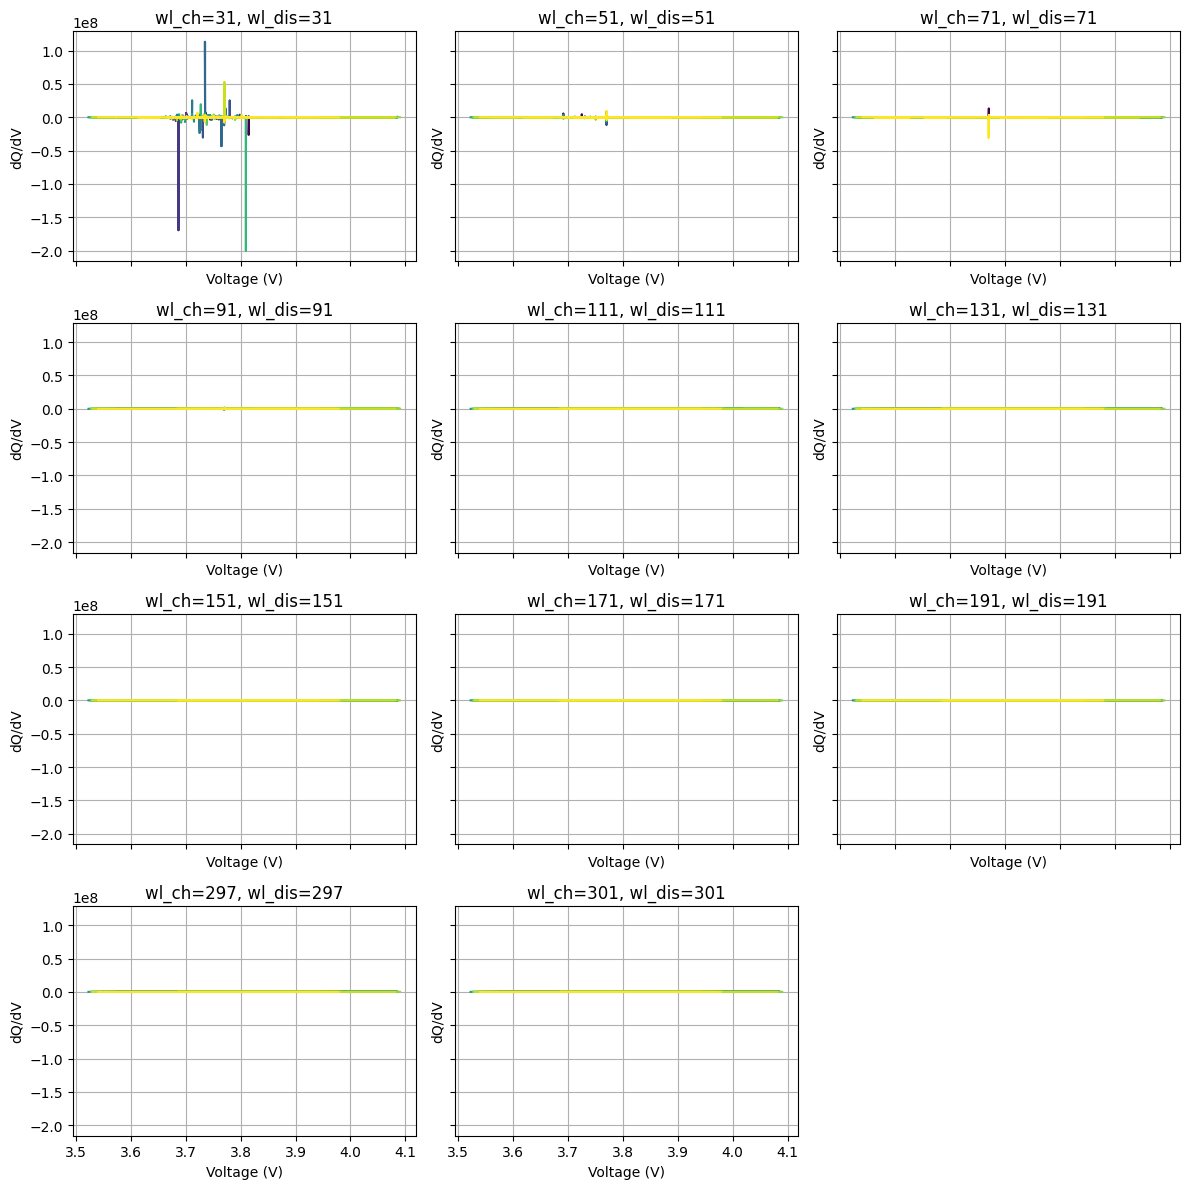

In [88]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_ag, wl_values_ch=[31,51,71,91,111,131,151,171,191,297,301], wl_values_dis=[31,51,71,91,111,131,151,171,191,297,301], truncar_values=((2000,1000),(1000,2000)), CellV='V_round', Q='agg-Q')

## Ahora hago aggregate pero ademas redondeando (bajando resolución)

segun averigué el arbin tiene una incertidumbre de 1 mV, asi que redondeo hasta esa cifra y luego hago aggregate.

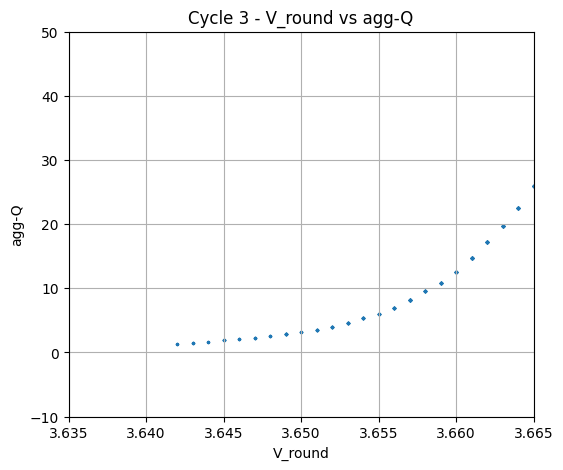

In [61]:
dict_ciclos_ag_red = dr.agrupar_por_voltaje_todos(dict_ciclos_sep, n_decimales=3, metodo='mean')

ciclo = 3
grafico_QV(ciclo, dict_ciclos_ag_red[ciclo]['Ch']['V_round'][80:], dict_ciclos_ag_red[ciclo]['Ch']['agg-Q'][80:], xlim=(3.635,3.665), ylim=(-10,50))

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


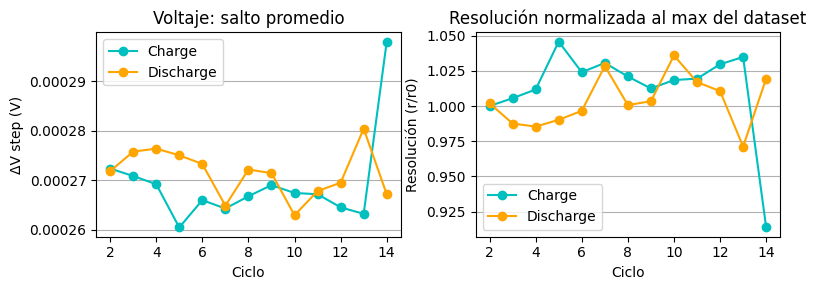

Puntos promedio por ventana de 2 mV:


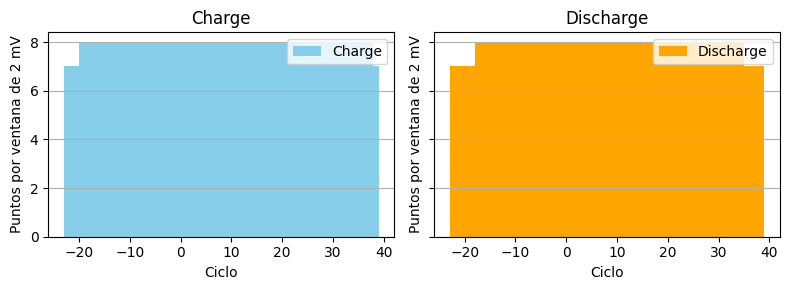

In [62]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_ag_red, x='V_round')

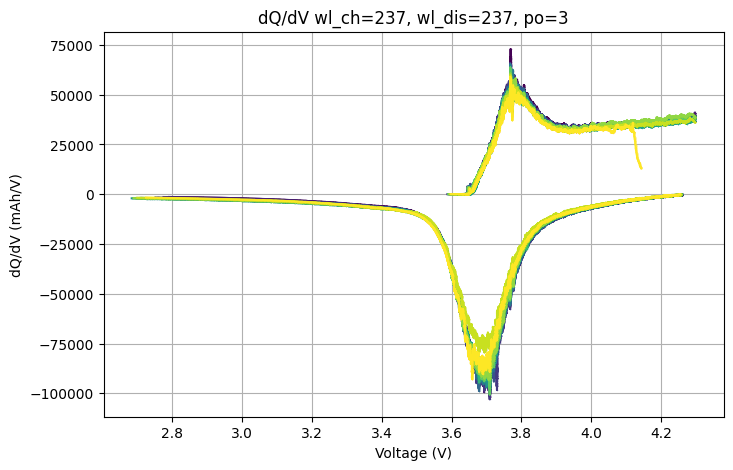

In [63]:
dict_ciclos_ag_red_truncado = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_ag_red.items()}
dict_ciclos_ag_red_truncado = dr.truncar_señal(ciclos_sel_todos, dict_ciclos_ag_red_truncado, Q='agg-Q', CellV='V_round', n_dis=(80,80), n_ch=(30,20))
dict_ciclos_ag_red_truncado =  dr.plot_dqdV(ciclos_sel_todos, dict_ciclos_ag_red_truncado, Q='agg-Q', CellV='V_round', wl_dis=237, wl_ch=237)

In [69]:
reload(dr)

<module 'deriv' from '/home/mariajose/proc-icdv/src/deriv.py'>

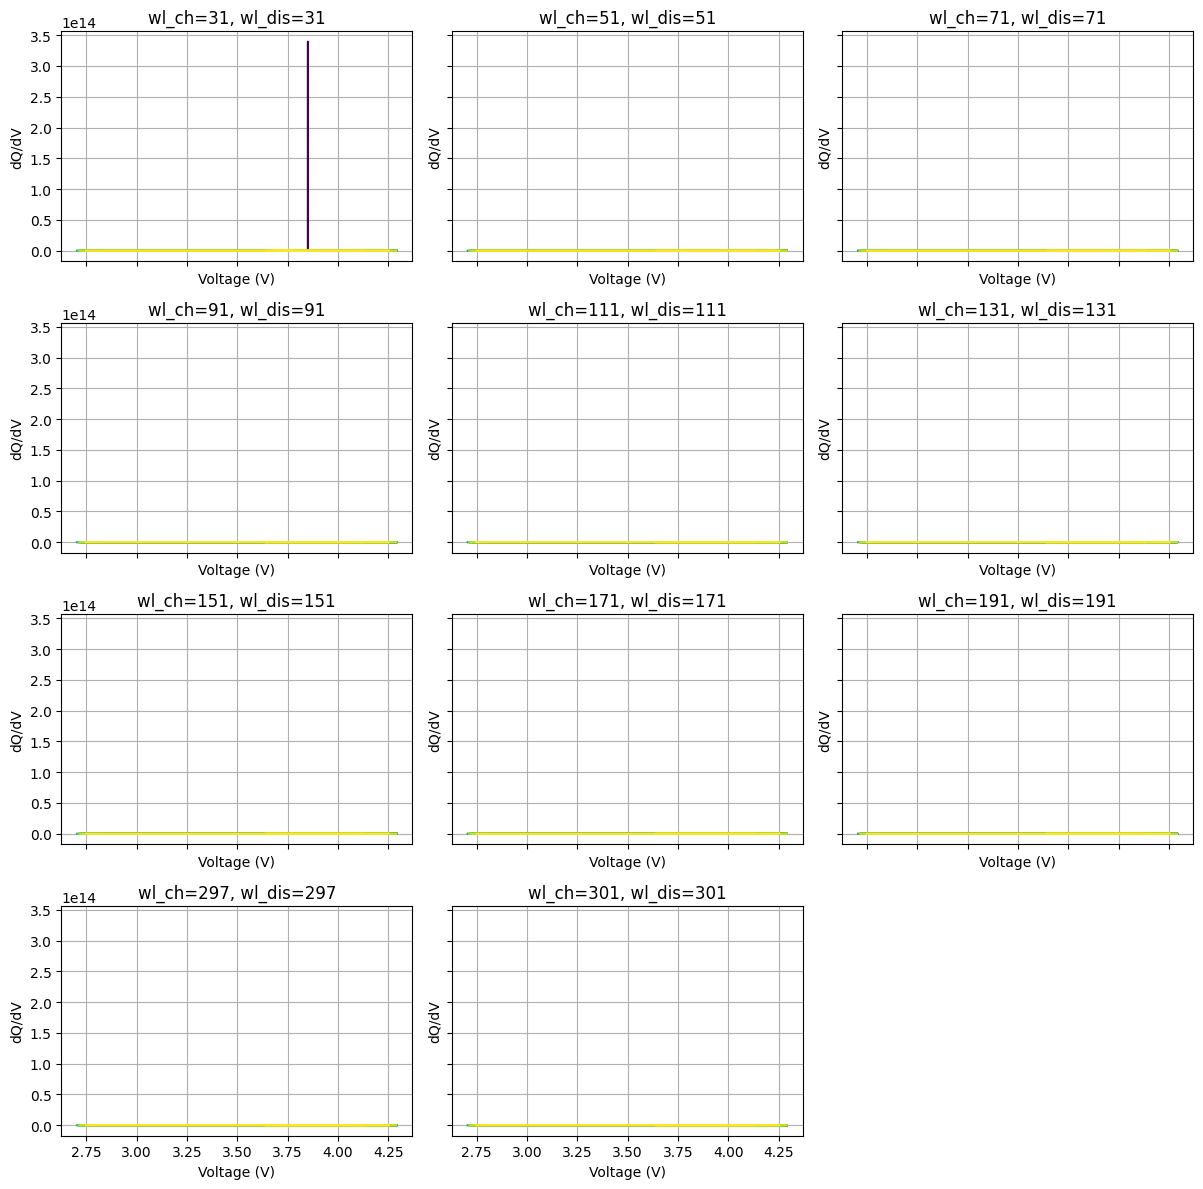

In [70]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_ag_red, wl_values_ch=[31,51,71,91,111,131,151,171,191,297,301], wl_values_dis=[31,51,71,91,111,131,151,171,191,297,301], truncar_values=((90,90),(90,90)), CellV='V_round', Q='agg-Q')

## Esto es si quiero derivar normal, sin aggrerate

In [29]:
reload(dr)

<module 'deriv' from '/home/mariajose/proc-icdv/src/deriv.py'>

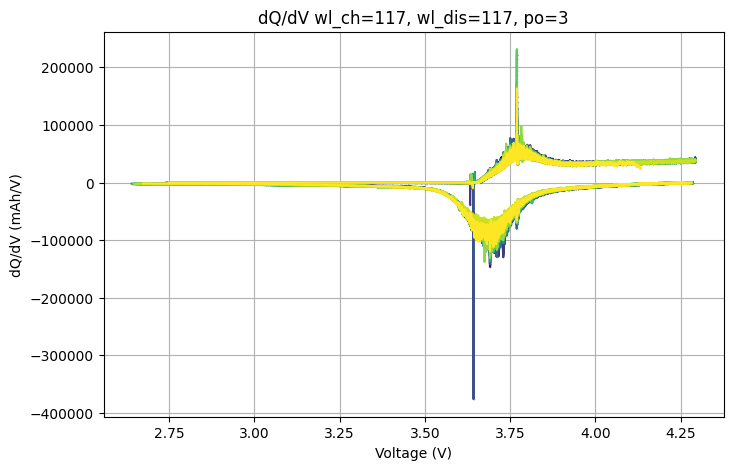

In [30]:
diccio_todos = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_sep.items()}
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=(60,60), n_ch=(60,60))
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=117, wl_ch=117)


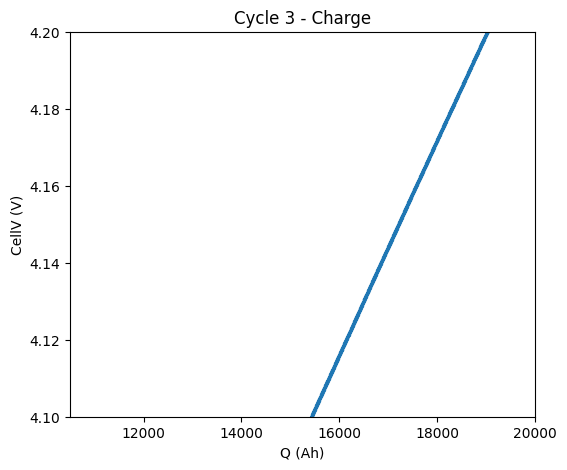

In [217]:
voltage = diccio_todos[3]['Ch']['V_ch_savgol'][26:]  # trunco los primeros 20 puntos ruidosos
Q = diccio_todos[3]['Ch']['Q_ch_savgol'][26:]

plt.figure(figsize=(6, 5))
plt.scatter(Q, voltage, s=2)
plt.xlabel('Q (Ah)')
plt.ylabel('CellV (V)')
plt.title('Cycle 3 - Charge')
#plt.ylim(3.75,3.8)
#plt.xlim(2500,3500)

plt.ylim(4.1,4.2)
plt.xlim(10500,20000)

plt.show()

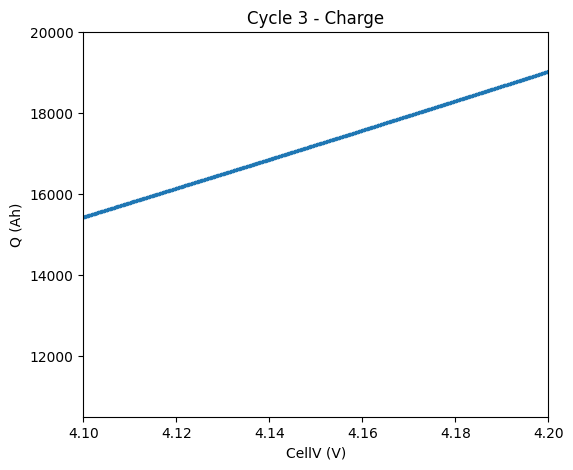

In [192]:
voltage = diccio_todos[3]['Ch']['V_ch_savgol'][80:]  # trunco los primeros 20 puntos ruidosos
Q = diccio_todos[3]['Ch']['Q_ch_savgol'][80:]

plt.figure(figsize=(6, 5))
plt.scatter(voltage, Q, s=2)
plt.xlabel('CellV (V)')
plt.ylabel('Q (Ah)')
plt.title('Cycle 3 - Charge')
#plt.xlim(3.75,3.8)
#plt.ylim(2500,3500)

plt.xlim(4.1,4.2)
plt.ylim(10500,20000)

plt.show()

/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/lib/_fun

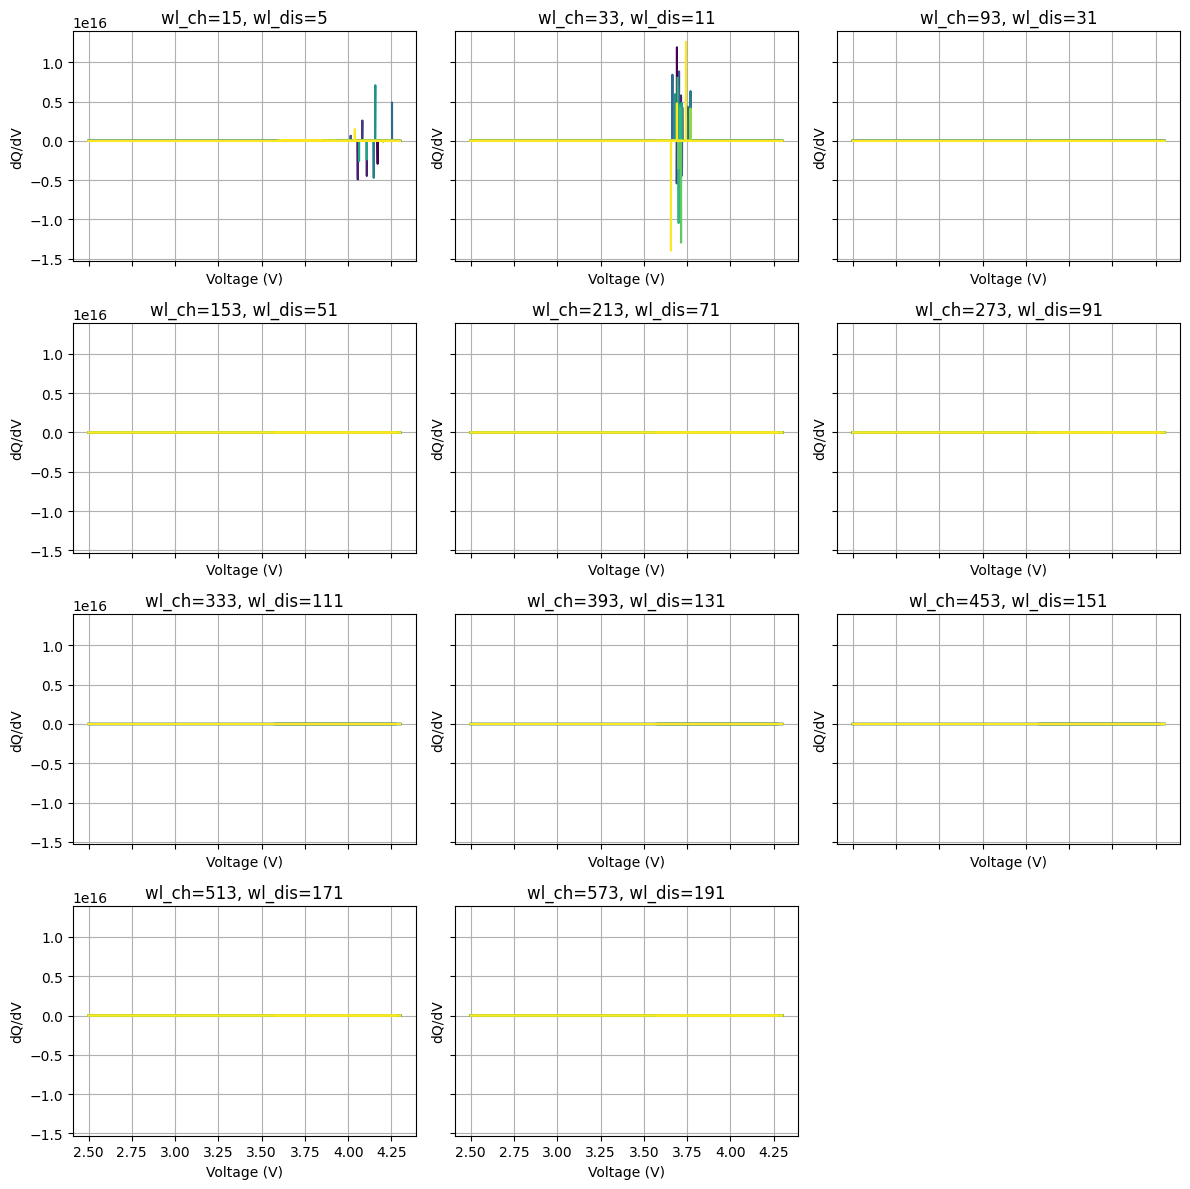

In [76]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_sep, wl_values=[5,11,31,51,71,91,111,131,151,171,191], truncar_values=(25,25))

## Calculo derivada con los parámetros dados

> En este conjunto de datos, la señal de carga tiene **3 veces más resolución** que la de descarga.  
> Estos valores pueden cambiar según el dataset.  
>  
> **NMC-20**  
> • Carga: ventana = **153**, truncar **30** puntos iniciales  
> • Descarga: ventana = **51** (153/3), truncar **10** puntos finales (30/3)  
>  
> **NMC-10**  
> • Carga: ventana = **213**, truncar **30** puntos iniciales  
> • Descarga: ventana = **71**, truncar **10** puntos finales  

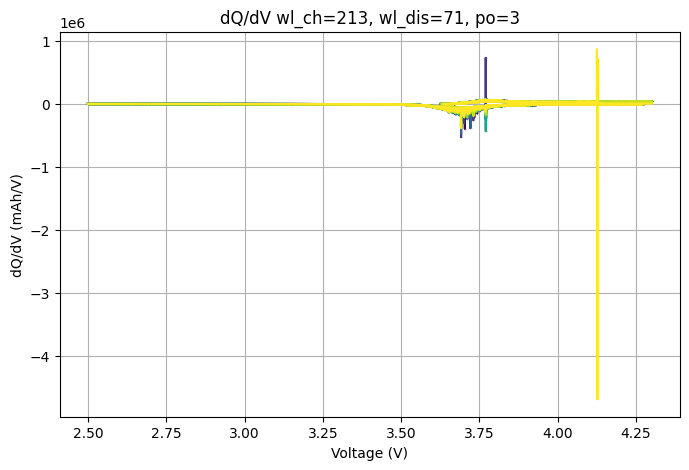

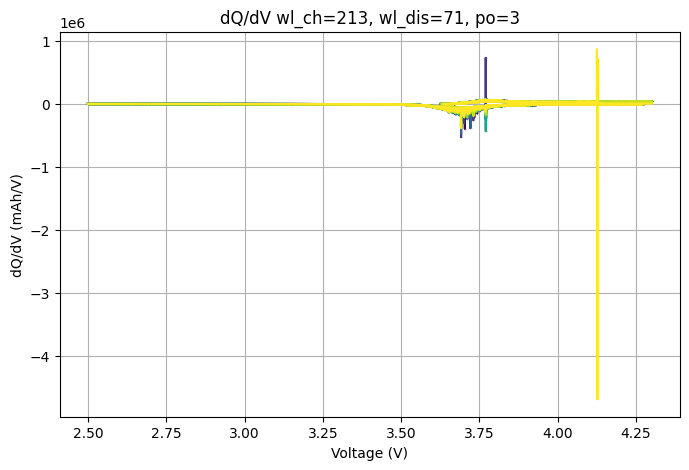

In [56]:
# --- Trunco datos y calculo derivada ---

diccio_grafico = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()}  for ciclo, df in dict_ciclos_sep.items()}
diccio_grafico = dr.truncar_señal(ciclos_sel_grafico, diccio_grafico, n_dis=20, n_ch=60)
diccio_grafico =  dr.plot_dqdV(ciclos_sel_grafico, diccio_grafico, wl_dis=71, wl_ch=213)

diccio_todos = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_sep.items()}
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=20, n_ch=60)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=71, wl_ch=213)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)